### QPMwP CODING EXAMPLES: Factors

Demo file which constructs factor series from the JKP data as long-short portfolios, going long a top quintile portfolio and short a bottom quintile portfolio. 

In [4]:
# Standard library imports
import os
import sys

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))  # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    load_pickle,
    load_data_spi,
    load_jkp_factor_series,                                      # NEW
    align_market_data_with_jkp_data,                             # NEW
)
from optimization.optimization import PercentilePortfolio        # NEW
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_scores,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

## Constants

In [ ]:
PATH_TO_DATA = ''     # <change this to your path to data>
SAVE_PATH = ''        # <change this to your path where you want to store the backtest>



JKP_FIELDS_VALUE = [
    'at_me',
    'be_me',
    'bev_mev',
    'debt_me',
    'div12m_me',
    'ebitda_mev',
    'eq_dur',
    'eqnetis_at',
    'eqnpo_12m',
    'eqnpo_me',
    'fcf_me',
    'ival_me',
    'netis_at',
    'ni_me',
    'ocf_me',
    'sale_me',
]

JKP_FIELDS_QMJ = [
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'qmj',  
]

JKP_FIELDS_MOMENTUM = [
    'prc_highprc_252d',
    'resff3_6_1',
    'resff3_12_1',
    'ret_3_1',
    'ret_6_1',
    'ret_9_1',
    'ret_12_1',
    'seas_1_1na',
]

JKP_FIELDS_ML = [
    'ml_signal',
]

JKP_FIELDS = {
    'value': JKP_FIELDS_VALUE,
    'qmj': JKP_FIELDS_QMJ,
    'momentum': JKP_FIELDS_MOMENTUM,
    'ml': JKP_FIELDS_ML,
}



## Load data and initialize BacktestData class
- market data (from parquet file)
- jkp data (from parquet file)
- swiss performance index, SPI (from csv file)

In [9]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')
spi = load_data_spi(path='../data/')

# Load ML signal and add to jkp_data (so that we can use it in the backtest)
ml_signal = pd.read_parquet(path=f'{PATH_TO_DATA}ml_signal.parquet')
ml_signal = ml_signal.stack().squeeze()
ml_signal.name = 'ml_signal'
ml_signal.index.names = jkp_data.index.names

# Add the ml_signal to jkp_data
jkp_data = jkp_data.join(ml_signal, how='left')

# Align market data with jkp data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(market_data=market_data, jkp_data=jkp_data)

# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = spi

C:\Users\User\AppData\Local\Temp\ipykernel_13960\1541688368.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ml_signal = ml_signal.stack().squeeze()


In [10]:
# # Inspect the data

# # data.jkp_data[JKP_FIELDS_VALUE].loc['2023-06-30'].mean(axis=1)
# data.jkp_data[JKP_FIELDS_QMJ].loc['2023-06-30'].describe()
# data.jkp_data[JKP_FIELDS_VALUE].loc['2023-06-30'].describe()
# data.jkp_data[JKP_FIELDS_MOMENTUM].loc['2023-06-30'].describe()
# data.jkp_data[JKP_FIELDS_ML].loc['2023-06-30'].describe()

# # # Plot densities
# # data.jkp_data[JKP_FIELDS_QMJ].loc["2023-06-30"].plot(kind='density', legend=True)
# # data.jkp_data[JKP_FIELDS_VALUE].loc["2023-06-30"].plot(kind='density', legend=True)
# data.jkp_data[JKP_FIELDS_MOMENTUM].loc["2023-06-30"].plot(kind='density', legend=True)
# data.jkp_data[JKP_FIELDS_ML].loc["2023-06-30"].plot(kind='density', legend=True)


## Define a grid of rebalancing dates

In [11]:
n_month = 3 # We want to rebalance every n_month months
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
rebdates = [date for date in rebdates if date > '2002-01-01']
rebdates

['2002-01-31',
 '2002-04-30',
 '2002-07-31',
 '2002-10-31',
 '2003-01-31',
 '2003-04-30',
 '2003-07-31',
 '2003-10-31',
 '2004-01-31',
 '2004-04-30',
 '2004-07-31',
 '2004-10-31',
 '2005-01-31',
 '2005-04-30',
 '2005-07-31',
 '2005-10-31',
 '2006-01-31',
 '2006-04-30',
 '2006-07-31',
 '2006-10-31',
 '2007-01-31',
 '2007-04-30',
 '2007-07-31',
 '2007-10-31',
 '2008-01-31',
 '2008-04-30',
 '2008-07-31',
 '2008-10-31',
 '2009-01-31',
 '2009-04-30',
 '2009-07-31',
 '2009-10-31',
 '2010-01-31',
 '2010-04-30',
 '2010-07-31',
 '2010-10-31',
 '2011-01-31',
 '2011-04-30',
 '2011-07-31',
 '2011-10-31',
 '2012-01-31',
 '2012-04-30',
 '2012-07-31',
 '2012-10-31',
 '2013-01-31',
 '2013-04-30',
 '2013-07-31',
 '2013-10-31',
 '2014-01-31',
 '2014-04-30',
 '2014-07-31',
 '2014-10-31',
 '2015-01-31',
 '2015-04-30',
 '2015-07-31',
 '2015-10-31',
 '2016-01-31',
 '2016-04-30',
 '2016-07-31',
 '2016-10-31',
 '2017-01-31',
 '2017-04-30',
 '2017-07-31',
 '2017-10-31',
 '2018-01-31',
 '2018-04-30',
 '2018-07-

## Define the selection item builders

In [12]:
# factor_theme = 'qmj'
# factor_theme = 'momentum'
# factor_theme = 'value'
factor_theme = 'ml'

selection_item_builders = {
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365,
        min_volume=500_000,
        agg_fn=np.median,
    ),
    'jkp_data_scores': SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,                   
        fields=JKP_FIELDS[factor_theme],   # See jkp_data.columns for available fields
    ),
}

## Define the optimization item builders.

In [13]:
optimization_item_builders = {
    'scores': OptimizationItemBuilder(
        bibfn=bibfn_scores,
        fields=JKP_FIELDS[factor_theme],
    ),
}

## Initialize the backtest service

In [14]:
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## Run backtest for a top quintile portfolio (tqp)

In [36]:
# Update the backtest service with a PercentilePortfolio optimization object
bs.optimization = PercentilePortfolio(
    # field='qmj',
    # score_weights={
    #     'qmj_prof': 0.33,
    #     'qmj_growth': 0.33,
    #     'qmj_safety': 0.33,
    # },
    percentile=80,
    sign='>=',
)

# Instantiate the backtest object and run the backtest
bt_tqp = Backtest()

# Run the backtest
bt_tqp.run(bs=bs)

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

In [ ]:
# # Save the backtest as a .pickle file
# bt_tqp.save(
#     path=SAVE_PATH,
#     filename=f'demo_backtest_7_tqp_{factor_theme}.pickle'
# )

Backtest object saved successfully to C:/Users/User/OneDrive/Documents/QPMwP/2026/Code/demo_backtest_7_tqp_ml.pickle


## Run backtest for a bottom quintile portfolio (bqp)

In [30]:
# Update the backtest service with a PercentilePortfolio optimization object
bs.optimization = PercentilePortfolio(
    # field='qmj',
    # score_weights={
    #     'qmj_prof': 0.33,
    #     'qmj_growth': 0.33,
    #     'qmj_safety': 0.33,
    # },
    percentile=20,
    sign='<=',
)

# Instantiate the backtest object and run the backtest
bt_bqp = Backtest()

# Run the backtest
bt_bqp.run(bs=bs)

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

In [ ]:
# # Save the backtest as a .pickle file
# bt_bqp.save(
#     path=SAVE_PATH,
#     filename=f'demo_backtest_7_bqp_{factor_theme}.pickle'
# )

Backtest object saved successfully to C:/Users/User/OneDrive/Documents/QPMwP/2026/Code/demo_backtest_7_bqp_ml.pickle


## Simulate

<Axes: title={'center': 'Cumulative Performance'}>

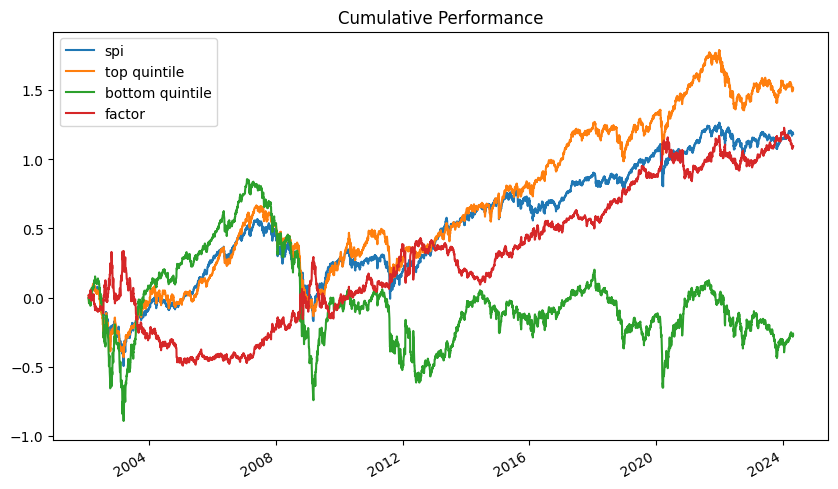

In [15]:
# factor_theme = 'qmj'
# factor_theme = 'momentum'
# factor_theme = 'momentum_xvolfilt'
# factor_theme = 'value'
factor_theme = 'ml'


# Laod backtests from pickle
bt_tqp = load_pickle(
    filename=f'demo_backtest_7_tqp_{factor_theme}.pickle',
    path=SAVE_PATH,
)
bt_bqp = load_pickle(
    filename=f'demo_backtest_7_bqp_{factor_theme}.pickle',
    path=SAVE_PATH,
)


fixed_costs = 0
variable_costs = 0
return_series = bs.data.get_return_series()

sim_tqp = bt_tqp.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)
sim_bqp = bt_bqp.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

# Concatenate the simulations
sim = pd.concat({
    'spi': bs.data.bm_series,
    'top quintile': sim_tqp,
    'bottom quintile': sim_bqp,
    'factor': sim_tqp - sim_bqp,
}, axis=1).dropna()


# Plot the cumulative performance
np.log((1 + sim)).cumsum().plot(title='Cumulative Performance', figsize=(10, 6))

### Compare to JKP factor series

<Axes: title={'center': 'Cumulative Performance'}, xlabel='date'>

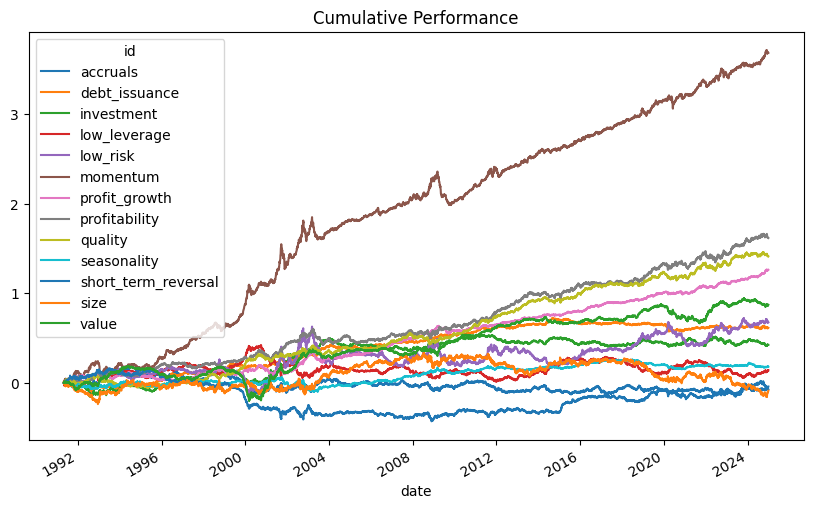

In [17]:
jkp_factor_series = load_jkp_factor_series(path='../data/')
jkp_factor_series

jkp_factor_series.corr()
jkp_factor_series.mean()

np.log((1 + jkp_factor_series)).cumsum().plot(title='Cumulative Performance', figsize=(10, 6))

## Factor Regression

In [25]:
import statsmodels.api as sm

# Prepare the regression data
regression_data = pd.concat({
    'y': sim_tqp,
    'spi': bs.data.bm_series,
    **jkp_factor_series.to_dict('series'),
}, axis=1)

# Drop NaN values
regression_data = regression_data.dropna()

# Aggregate from daily to monthly frequency (if needed)
regression_data = regression_data.resample('ME').apply(lambda x: (1 + x).prod() - 1)

# Define dependent and independent variables
y = regression_data['y']  # Dependent variable
X = regression_data.drop('y', axis=1)  # All other columns as independent variables

# Add constant term
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X)
results = model.fit()

# Display regression results
print("Regression Results: sim_factor_mix on constant, SPI, and factor return series")
print(results.summary())

Regression Results: sim_factor_mix on constant, SPI, and factor return series
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     64.90
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           4.05e-75
Time:                        14:27:50   Log-Likelihood:                 637.72
No. Observations:                 267   AIC:                            -1245.
Df Residuals:                     252   BIC:                            -1192.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------